# Данные о поездках на желтых такси в Нью-Йорке

### Подключене библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

### Подключение стилей

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

### Загрузка данных

In [3]:
df = pd.read_csv('yellow_tripdata_2016-02.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк данных:")
df.head()

Размер датасета: (11382049, 19)

Первые 5 строк данных:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-02-25 17:24:20,2016-02-25 17:27:20,2,0.70,-73.947250,40.763771,1,N,-73.992012,40.735390,2,5.0,0.0,0.5,0.0,0.0,0.3,5.8
1,2,2016-02-25 23:10:50,2016-02-25 23:31:50,2,5.52,-73.983017,40.750992,1,N,-73.988586,40.758839,2,20.0,0.5,0.5,0.0,0.0,0.3,21.3
2,2,2016-02-01 00:00:01,2016-02-01 00:10:52,6,1.99,-73.992340,40.758202,1,N,-73.964355,40.757977,1,9.5,0.5,0.5,0.7,0.0,0.3,11.5
3,1,2016-02-01 00:00:04,2016-02-01 00:05:16,1,1.50,-73.981453,40.749722,1,N,-73.982323,40.763985,2,6.5,0.5,0.5,0.0,0.0,0.3,7.8
4,2,2016-02-01 00:00:05,2016-02-01 00:20:59,1,5.60,-74.000603,40.729755,1,N,-73.951324,40.669834,1,20.0,0.5,0.5,4.0,0.0,0.3,25.3


In [4]:
print("Информация о датасете:")
df.info()

print("\nСтатистическое описание числовых признаков:")
df.describe()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               51 non-null     int64  
 1   tpep_pickup_datetime   51 non-null     object 
 2   tpep_dropoff_datetime  51 non-null     object 
 3   passenger_count        51 non-null     int64  
 4   trip_distance          51 non-null     float64
 5   pickup_longitude       51 non-null     float64
 6   pickup_latitude        51 non-null     float64
 7   RateCodeID             51 non-null     int64  
 8   store_and_fwd_flag     51 non-null     object 
 9   dropoff_longitude      51 non-null     float64
 10  dropoff_latitude       51 non-null     float64
 11  payment_type           51 non-null     int64  
 12  fare_amount            51 non-null     float64
 13  extra                  51 non-null     float64
 14  mta_tax                51 non-null   

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,5.100000e+01,51.000000
mean,1.686275,1.803922,3.195882,-72.517609,39.946791,1.137255,-72.526795,39.950740,1.294118,14.323529,0.647059,0.490196,1.906667,0.418039,3.000000e-01,18.085490
std,0.468623,1.483504,4.057600,10.357703,5.705630,0.600653,10.358953,5.706192,0.460179,12.839324,0.320844,0.070014,2.215115,1.447225,2.803176e-16,14.703826
min,1.000000,1.000000,0.010000,-74.009087,0.000000,1.000000,-74.009773,0.000000,1.000000,2.500000,0.000000,0.000000,0.000000,0.000000,3.000000e-01,3.800000
25%,1.000000,1.000000,1.165000,-73.993839,40.726927,1.000000,-73.996078,40.728563,1.000000,7.500000,0.500000,0.500000,0.000000,0.000000,3.000000e-01,9.980000
50%,2.000000,1.000000,2.050000,-73.985092,40.746208,1.000000,-73.984879,40.755371,1.000000,11.000000,0.500000,0.500000,1.660000,0.000000,3.000000e-01,13.800000
75%,2.000000,2.000000,3.055000,-73.964752,40.763012,1.000000,-73.960567,40.763544,2.000000,14.750000,1.000000,0.500000,2.430000,0.000000,3.000000e-01,17.425000
max,2.000000,6.000000,18.200000,0.000000,40.823994,5.000000,0.000000,40.824413,2.000000,60.000000,1.000000,0.500000,10.000000,5.330000,3.000000e-01,64.130000


In [5]:
# Ячейка 4: Проверка пропущенных значений
print("Пропущенные значения в каждом столбце:")
print(df.isnull().sum())

print("\nТипы данных:")
print(df.dtypes)

Пропущенные значения в каждом столбце:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RateCodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

Типы данных:
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RateCodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              

In [6]:
# Ячейка 5: Преобразование дат
# Преобразуем строковые даты в datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Создаем новые признаки на основе времени
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_weekday'] = df['tpep_pickup_datetime'].dt.dayofweek
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

print("Новые признаки созданы:")
df[['pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'trip_duration_minutes']].head()

Новые признаки созданы:


,pickup_hour,pickup_day,pickup_month,pickup_weekday,trip_duration_minutes
0,19,15,1,3,18.0
1,20,10,1,5,20.0
2,20,10,1,5,10.0
3,20,10,1,5,2.0
4,20,10,1,5,19.0


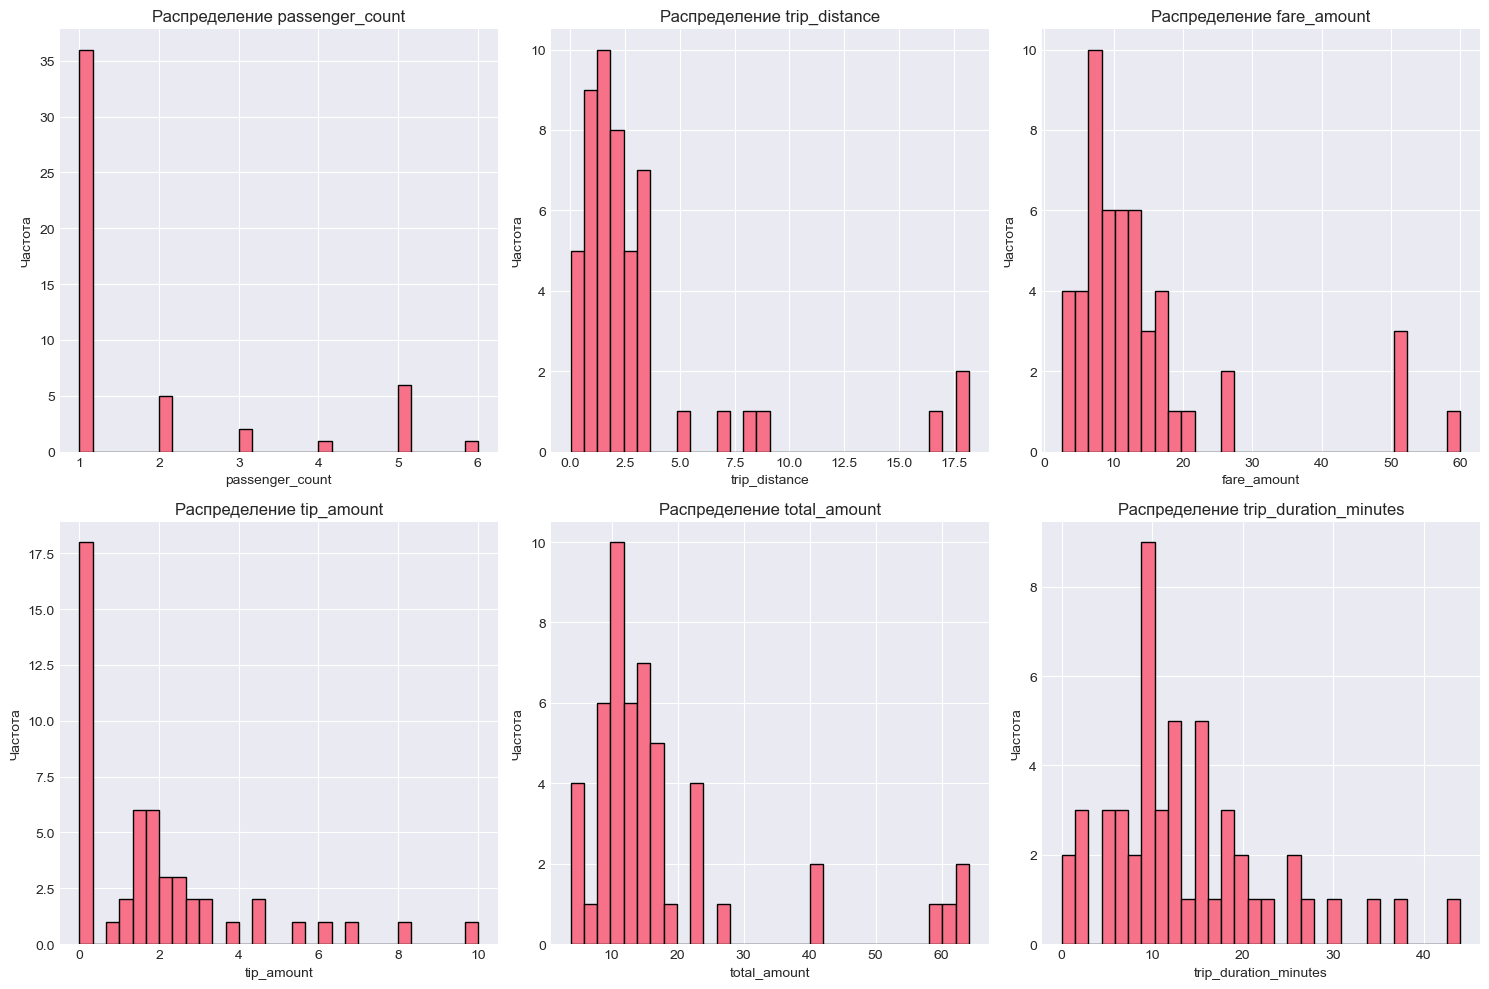

In [7]:
# Ячейка 6: Визуализация распределений
# Создаем подграфики для основных числовых признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount', 
                'tip_amount', 'total_amount', 'trip_duration_minutes']

for i, col in enumerate(numeric_cols):
    row = i // 3
    col_idx = i % 3
    axes[row, col_idx].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[row, col_idx].set_title(f'Распределение {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()

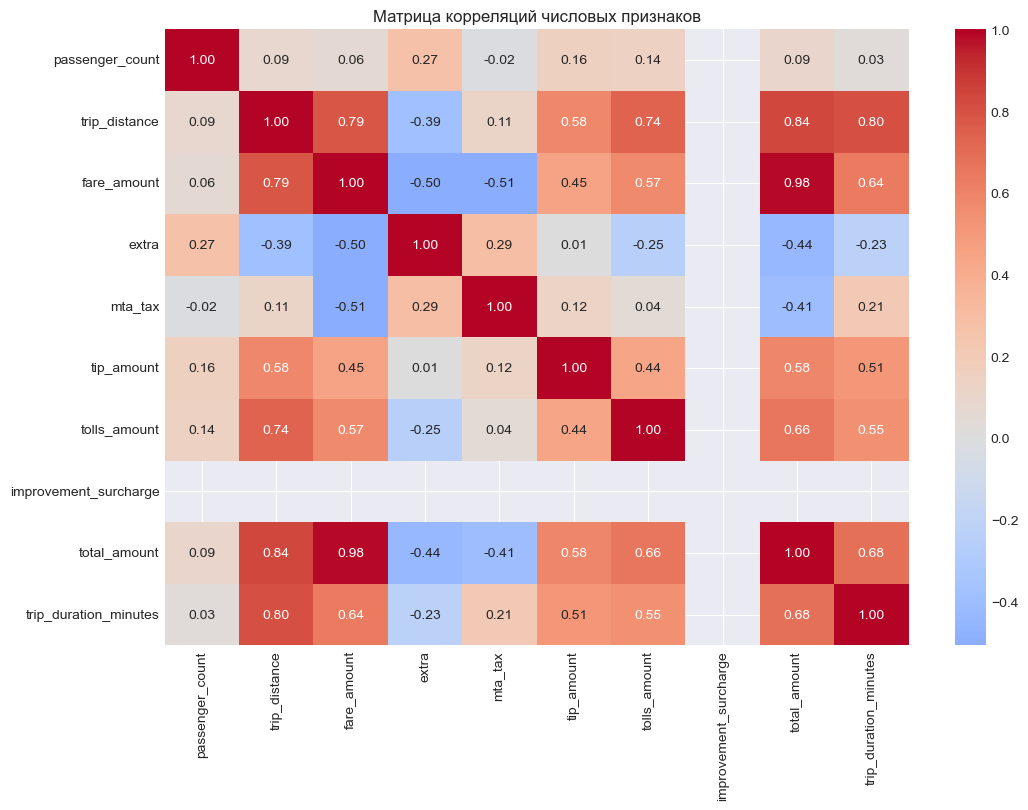

Наиболее важные признаки (сильная корреляция с total_amount):
total_amount             1.000000
fare_amount              0.983383
trip_distance            0.837510
trip_duration_minutes    0.681278
tolls_amount             0.658534
tip_amount               0.584616
passenger_count          0.094700
mta_tax                 -0.410059
extra                   -0.440946
improvement_surcharge         NaN
Name: total_amount, dtype: float64


In [8]:
# Ячейка 7: Анализ важности признаков (корреляция)
# Выбираем числовые признаки для корреляции
numeric_features = ['passenger_count', 'trip_distance', 'fare_amount', 
                   'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 
                   'improvement_surcharge', 'total_amount', 'trip_duration_minutes']

# Строим матрицу корреляций
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций числовых признаков')
plt.show()

print("Наиболее важные признаки (сильная корреляция с total_amount):")
corr_with_total = correlation_matrix['total_amount'].sort_values(ascending=False)
print(corr_with_total)

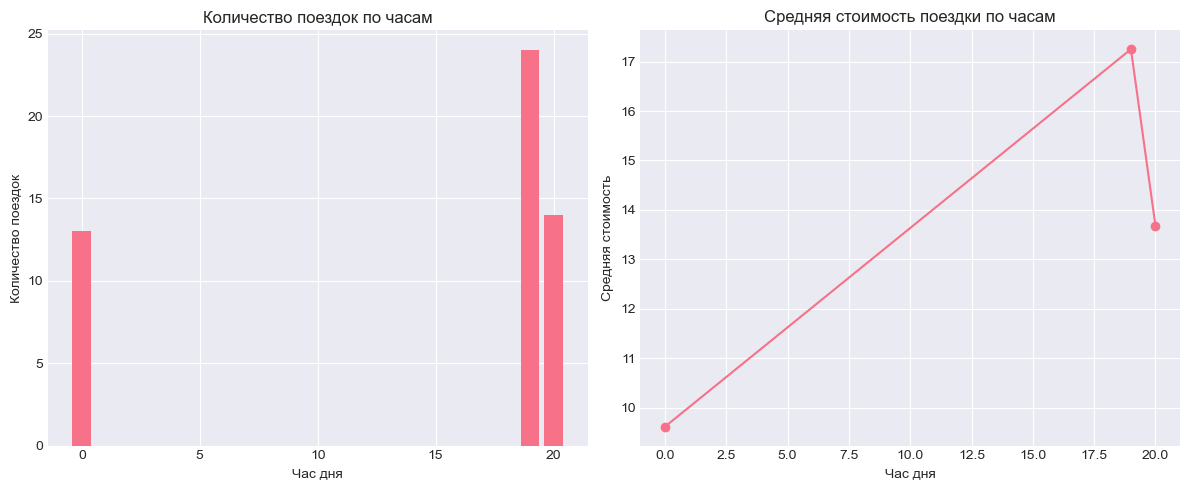

In [9]:
# Ячейка 8: Анализ по часам
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
hourly_trips = df['pickup_hour'].value_counts().sort_index()
plt.bar(hourly_trips.index, hourly_trips.values)
plt.title('Количество поездок по часам')
plt.xlabel('Час дня')
plt.ylabel('Количество поездок')

plt.subplot(1, 2, 2)
hourly_fare = df.groupby('pickup_hour')['fare_amount'].mean()
plt.plot(hourly_fare.index, hourly_fare.values, marker='o')
plt.title('Средняя стоимость поездки по часам')
plt.xlabel('Час дня')
plt.ylabel('Средняя стоимость')

plt.tight_layout()
plt.show()

In [10]:
# Ячейка 9: Подготовка данных для кластеризации
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Выбираем признаки для кластеризации
features_for_clustering = ['trip_distance', 'fare_amount', 'tip_amount', 
                          'passenger_count', 'trip_duration_minutes']

# Удаляем строки с пропущенными значениями
df_clean = df[features_for_clustering].dropna()

# Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print("Данные подготовлены для кластеризации. Размер:", X_scaled.shape)

Данные подготовлены для кластеризации. Размер: (51, 5)


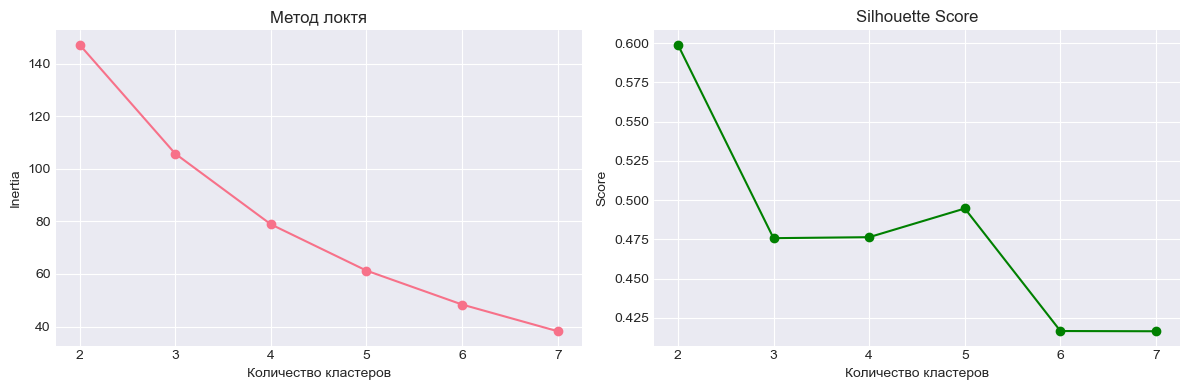

Лучший silhouette score: 0.599 при k=2


In [11]:
# Ячейка 10: Кластеризация методом K-Means
# Определяем оптимальное количество кластеров
inertia = []
silhouette_scores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Визуализация для выбора оптимального k
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(2, 8), inertia, marker='o')
axes[0].set_title('Метод локтя')
axes[0].set_xlabel('Количество кластеров')
axes[0].set_ylabel('Inertia')

axes[1].plot(range(2, 8), silhouette_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Количество кластеров')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

print(f"Лучший silhouette score: {max(silhouette_scores):.3f} при k={silhouette_scores.index(max(silhouette_scores))+2}")

In [12]:
# Ячейка 11: Применяем K-Means с оптимальным k
optimal_k = 3  # или другое значение на основе графика
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Метрики для K-Means
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"K-Means (k={optimal_k}):")
print(f"Silhouette Score: {kmeans_silhouette:.3f}")
print(f"Davies-Bouldin Index: {kmeans_db:.3f}")

K-Means (k=3):
Silhouette Score: 0.476
Davies-Bouldin Index: 0.774


In [13]:
# Ячейка 12: Кластеризация методом DBSCAN (исправленная)
from sklearn.cluster import DBSCAN

# Подбираем параметры для DBSCAN
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 7]

best_score = -1
best_params = None
best_labels = None

print("Поиск оптимальных параметров DBSCAN:")
print("-" * 50)

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        # Проверяем, что получилось больше одного кластера
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters > 1:
            try:
                score = silhouette_score(X_scaled, labels)
                print(f"eps={eps}, min_samples={min_samples}: {n_clusters} кластеров, {n_noise} шумовых, silhouette={score:.3f}")
                
                if score > best_score:
                    best_score = score
                    best_params = (eps, min_samples)
                    best_labels = labels
            except:
                print(f"eps={eps}, min_samples={min_samples}: ошибка вычисления силуэта")
        else:
            print(f"eps={eps}, min_samples={min_samples}: только 1 кластер или все точки - шум")

print("\n" + "=" * 50)
if best_params:
    print(f"Лучшие параметры DBSCAN: eps={best_params[0]}, min_samples={best_params[1]}")
    print(f"Лучший Silhouette Score: {best_score:.3f}")
else:
    print("Не удалось найти подходящие параметры. Используем значения по умолчанию.")
    best_params = (0.5, 5)

Поиск оптимальных параметров DBSCAN:
--------------------------------------------------
eps=0.3, min_samples=3: 4 кластеров, 34 шумовых, silhouette=-0.065
eps=0.3, min_samples=5: только 1 кластер или все точки - шум
eps=0.3, min_samples=7: только 1 кластер или все точки - шум
eps=0.5, min_samples=3: 2 кластеров, 22 шумовых, silhouette=0.260
eps=0.5, min_samples=5: 2 кластеров, 31 шумовых, silhouette=0.041
eps=0.5, min_samples=7: только 1 кластер или все точки - шум
eps=0.7, min_samples=3: 2 кластеров, 16 шумовых, silhouette=0.345
eps=0.7, min_samples=5: только 1 кластер или все точки - шум
eps=0.7, min_samples=7: только 1 кластер или все точки - шум
eps=1.0, min_samples=3: 3 кластеров, 9 шумовых, silhouette=0.355
eps=1.0, min_samples=5: только 1 кластер или все точки - шум
eps=1.0, min_samples=7: только 1 кластер или все точки - шум

Лучшие параметры DBSCAN: eps=1.0, min_samples=3
Лучший Silhouette Score: 0.355


In [16]:
# Ячейка 13: Применяем DBSCAN с лучшими параметрами (исправленная)
if best_params:
    dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1])
    dbscan_labels = dbscan.fit_predict(X_scaled)
else:
    # Если best_params не определен, используем значения по умолчанию
    print("Используем параметры по умолчанию: eps=0.5, min_samples=5")
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nРЕЗУЛЬТАТЫ DBSCAN:")
print("=" * 50)
print(f"Количество кластеров: {n_clusters_dbscan}")
print(f"Количество шумовых точек: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    print(f"Silhouette Score: {dbscan_silhouette:.3f}")
else:
    print("Silhouette Score: невозможно вычислить (меньше 2 кластеров)")


РЕЗУЛЬТАТЫ DBSCAN:
Количество кластеров: 3
Количество шумовых точек: 9 (17.6%)
Silhouette Score: 0.355


In [17]:
# Ячейка 14: Иерархическая кластеризация
agglo = AgglomerativeClustering(n_clusters=optimal_k)
agglo_labels = agglo.fit_predict(X_scaled)

agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
agglo_db = davies_bouldin_score(X_scaled, agglo_labels)

print(f"Иерархическая кластеризация (k={optimal_k}):")
print(f"Silhouette Score: {agglo_silhouette:.3f}")
print(f"Davies-Bouldin Index: {agglo_db:.3f}")

Иерархическая кластеризация (k=3):
Silhouette Score: 0.434
Davies-Bouldin Index: 1.079


In [18]:
# Ячейка 15: Сравнение методов кластеризации
print("СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ:")
print("-" * 50)
print(f"{'Метод':<20} {'Silhouette':<15} {'Davies-Bouldin':<15}")
print("-" * 50)
print(f"{'K-Means':<20} {kmeans_silhouette:<15.3f} {kmeans_db:<15.3f}")
print(f"{'DBSCAN':<20} {silhouette_score(X_scaled, dbscan_labels):<15.3f} {'N/A':<15}")
print(f"{'Hierarchical':<20} {agglo_silhouette:<15.3f} {agglo_db:<15.3f}")

СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ:
--------------------------------------------------
Метод                Silhouette      Davies-Bouldin 
--------------------------------------------------
K-Means              0.476           0.774          
DBSCAN               0.355           N/A            
Hierarchical         0.434           1.079          


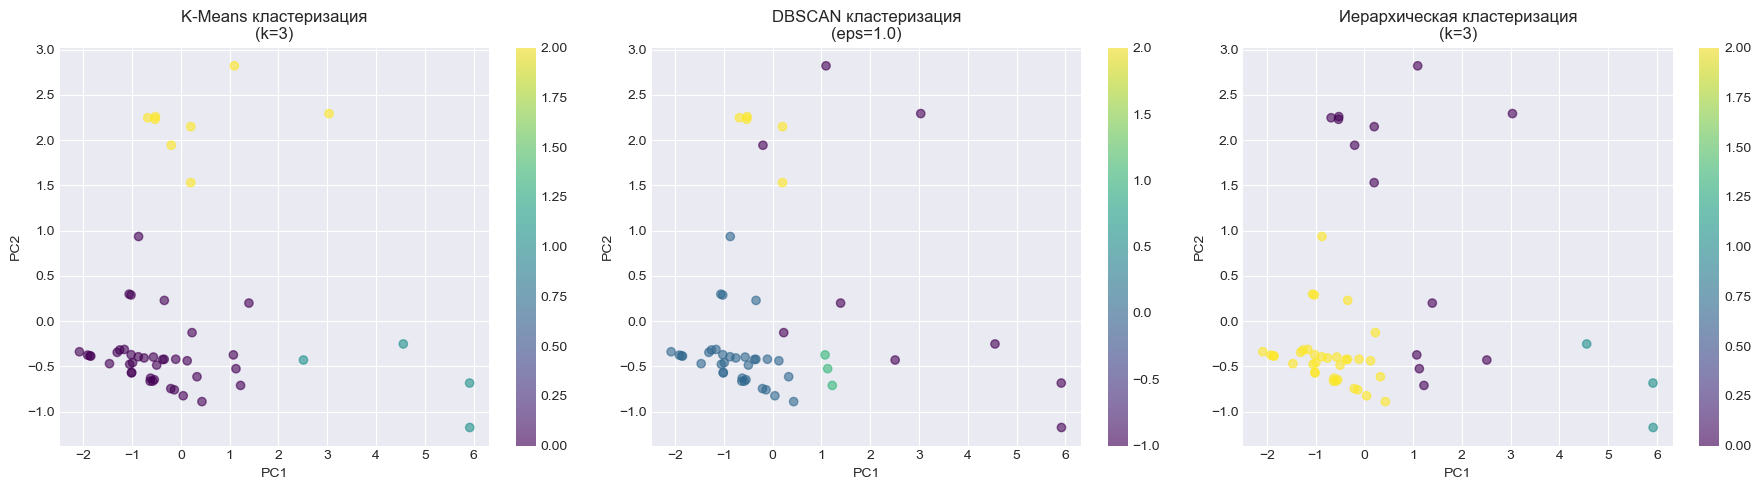

Объясненная дисперсия PCA: 78.47%


In [19]:
# Ячейка 16: Визуализация кластеров (PCA) - исправленная
from sklearn.decomposition import PCA

# Уменьшаем размерность для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Визуализация для каждого метода
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
axes[0].set_title(f'K-Means кластеризация\n(k={optimal_k})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

# DBSCAN
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.6)
axes[1].set_title(f'DBSCAN кластеризация\n(eps={best_params[0] if best_params else 0.5})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

# Hierarchical
scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='viridis', alpha=0.6)
axes[2].set_title(f'Иерархическая кластеризация\n(k={optimal_k})')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Объясненная дисперсия PCA: {pca.explained_variance_ratio_.sum():.2%}")

In [20]:
# Ячейка 17: Описание кластеров (для K-Means)
# Добавляем метки кластеров в исходный DataFrame
df_clustered = df_clean.copy()
df_clustered['Cluster'] = kmeans_labels

# Описание кластеров
print("ОПИСАНИЕ КЛАСТЕРОВ (K-Means):")
print("=" * 60)

for cluster in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster]
    print(f"\nКластер {cluster}:")
    print(f"Размер: {len(cluster_data)} поездок ({len(cluster_data)/len(df_clustered)*100:.1f}%)")
    print("\nСредние значения:")
    print(cluster_data[features_for_clustering].mean().round(2))
    print("\nМедианные значения:")
    print(cluster_data[features_for_clustering].median().round(2))
    print("-" * 40)

ОПИСАНИЕ КЛАСТЕРОВ (K-Means):

Кластер 0:
Размер: 39 поездок (76.5%)

Средние значения:
trip_distance             1.92
fare_amount              11.37
tip_amount                1.33
passenger_count           1.18
trip_duration_minutes    11.82
dtype: float64

Медианные значения:
trip_distance             1.73
fare_amount              10.00
tip_amount                1.50
passenger_count           1.00
trip_duration_minutes    11.00
dtype: float64
----------------------------------------

Кластер 1:
Размер: 4 поездок (7.8%)

Средние значения:
trip_distance            15.42
fare_amount              45.75
tip_amount                5.68
passenger_count           1.50
trip_duration_minutes    34.00
dtype: float64

Медианные значения:
trip_distance            17.23
fare_amount              52.00
tip_amount                6.35
passenger_count           1.00
trip_duration_minutes    36.00
dtype: float64
----------------------------------------

Кластер 2:
Размер: 8 поездок (15.7%)

Средние значе

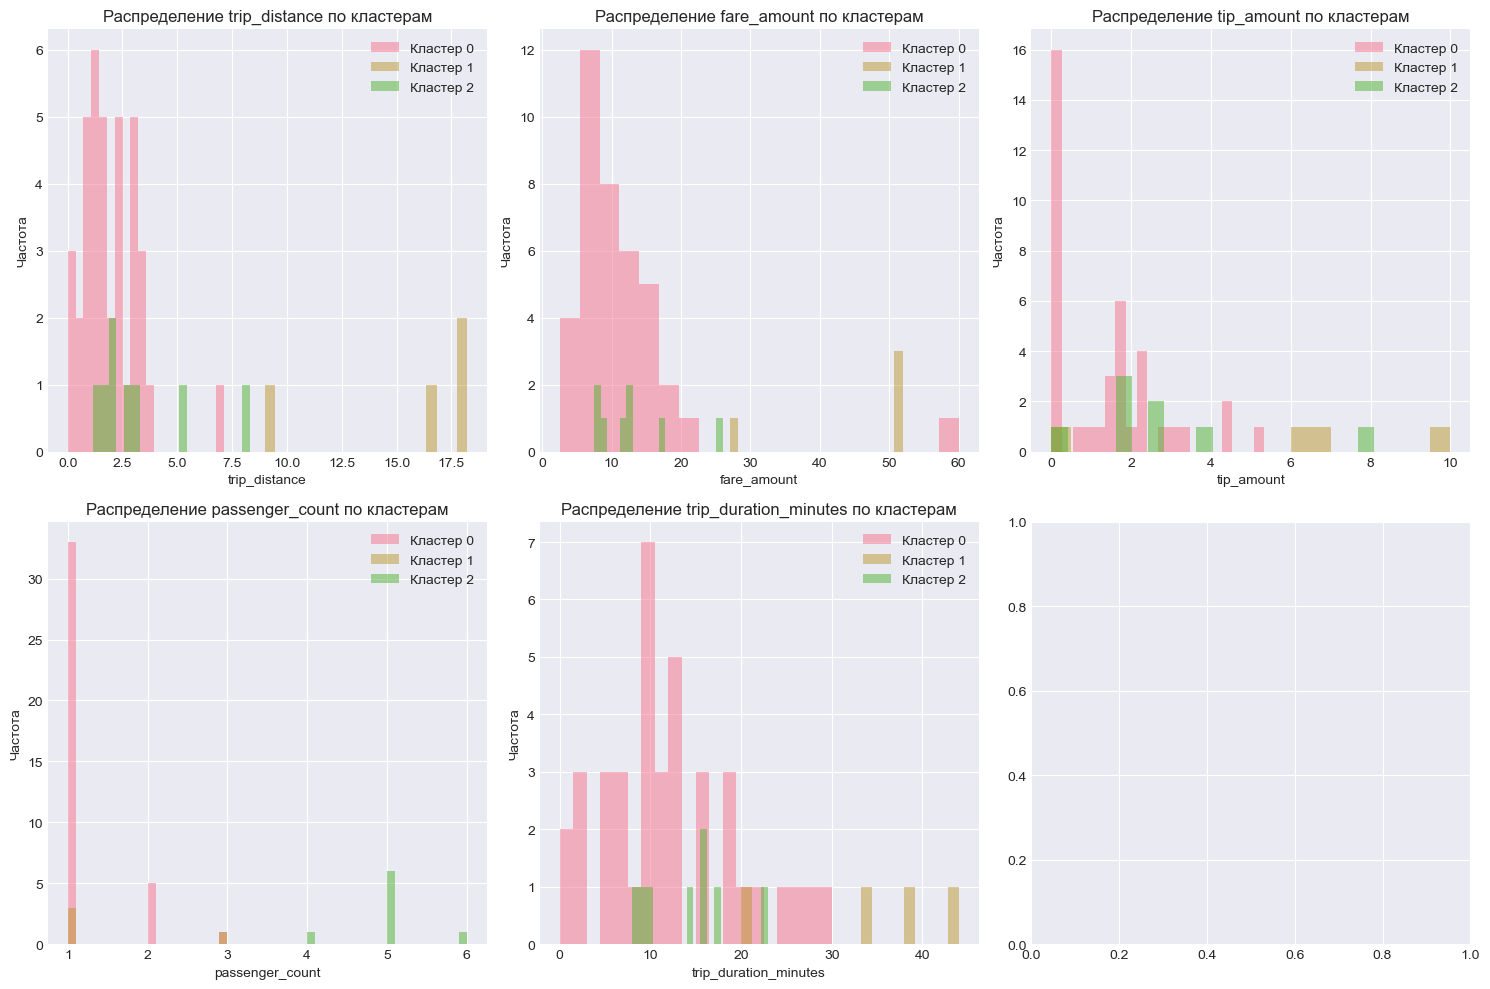

In [21]:
# Ячейка 18: Визуализация характеристик кластеров
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, feature in enumerate(features_for_clustering[:5]):  # Берем первые 5 признаков
    row = i // 3
    col = i % 3
    
    for cluster in range(optimal_k):
        cluster_data = df_clustered[df_clustered['Cluster'] == cluster][feature]
        axes[row, col].hist(cluster_data, alpha=0.5, label=f'Кластер {cluster}', bins=20)
    
    axes[row, col].set_title(f'Распределение {feature} по кластерам')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Частота')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

In [22]:
# Ячейка 19: Подготовка данных для классификации
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Создаем целевую переменную (например, размер чаевых)
df['tip_category'] = pd.cut(df['tip_amount'], 
                            bins=[-1, 0, 2, 5, 100], 
                            labels=['no_tip', 'small_tip', 'medium_tip', 'large_tip'])

# Выбираем признаки для классификации
feature_cols = ['passenger_count', 'trip_distance', 'fare_amount', 
                'pickup_hour', 'pickup_weekday', 'trip_duration_minutes']

# Удаляем строки с пропущенными значениями
df_class = df[feature_cols + ['tip_category']].dropna()

# Разделяем на признаки и целевую переменную
X = df_class[feature_cols]
y = df_class['tip_category']

# Кодируем целевую переменную
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Классы: {le.classes_}")

Размер обучающей выборки: (40, 6)
Размер тестовой выборки: (11, 6)
Классы: ['large_tip' 'medium_tip' 'no_tip' 'small_tip']


ДЕРЕВО РЕШЕНИЙ:
Accuracy: 0.909

Classification Report:
              precision    recall  f1-score   support

   large_tip       0.50      1.00      0.67         1
  medium_tip       1.00      1.00      1.00         3
      no_tip       1.00      0.75      0.86         4
   small_tip       1.00      1.00      1.00         3

    accuracy                           0.91        11
   macro avg       0.88      0.94      0.88        11
weighted avg       0.95      0.91      0.92        11



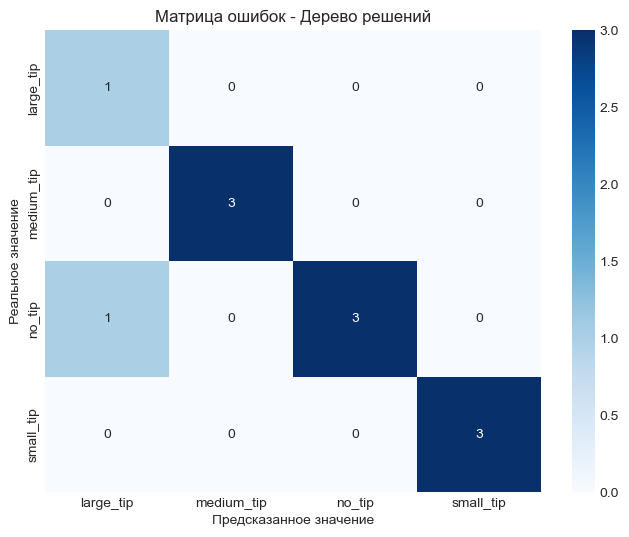

In [23]:
# Ячейка 20: Модель 1 - Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Предсказание
dt_pred = dt_model.predict(X_test)

# Метрики
dt_accuracy = accuracy_score(y_test, dt_pred)

print("ДЕРЕВО РЕШЕНИЙ:")
print(f"Accuracy: {dt_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=le.classes_))

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок - Дерево решений')
plt.ylabel('Реальное значение')
plt.xlabel('Предсказанное значение')
plt.show()

СЛУЧАЙНЫЙ ЛЕС:
Accuracy: 0.727

Classification Report:
              precision    recall  f1-score   support

   large_tip       1.00      1.00      1.00         1
  medium_tip       1.00      0.33      0.50         3
      no_tip       0.60      0.75      0.67         4
   small_tip       0.75      1.00      0.86         3

    accuracy                           0.73        11
   macro avg       0.84      0.77      0.76        11
weighted avg       0.79      0.73      0.70        11



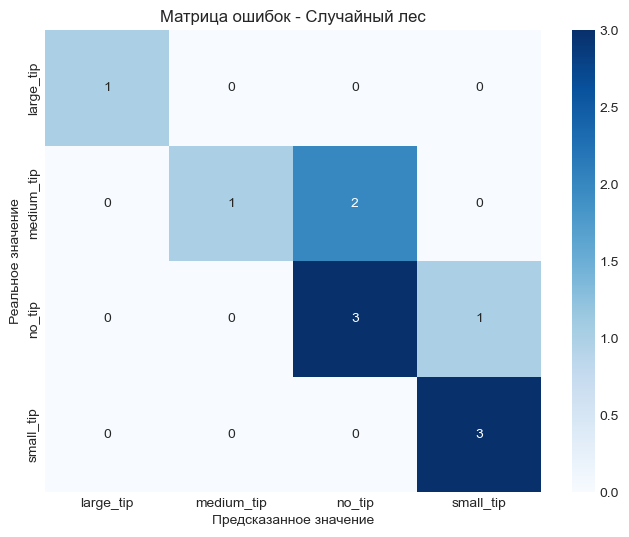

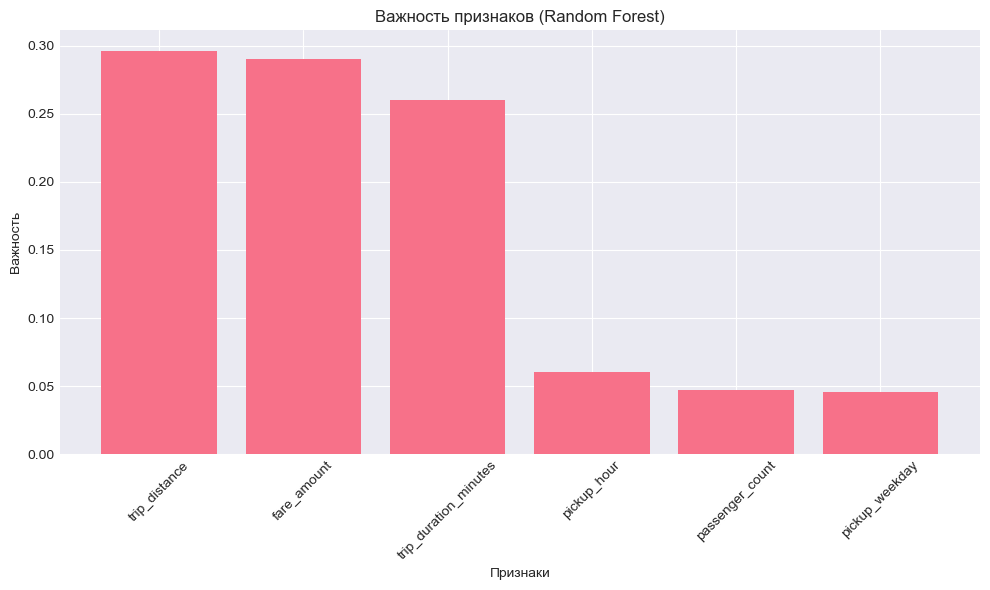

In [24]:
# Ячейка 21: Модель 2 - Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Предсказание
rf_pred = rf_model.predict(X_test)

# Метрики
rf_accuracy = accuracy_score(y_test, rf_pred)

print("СЛУЧАЙНЫЙ ЛЕС:")
print(f"Accuracy: {rf_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок - Случайный лес')
plt.ylabel('Реальное значение')
plt.xlabel('Предсказанное значение')
plt.show()

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

GRADIENT BOOSTING:
Accuracy: 0.818

Classification Report:
              precision    recall  f1-score   support

   large_tip       1.00      1.00      1.00         1
  medium_tip       1.00      0.33      0.50         3
      no_tip       0.67      1.00      0.80         4
   small_tip       1.00      1.00      1.00         3

    accuracy                           0.82        11
   macro avg       0.92      0.83      0.82        11
weighted avg       0.88      0.82      0.79        11



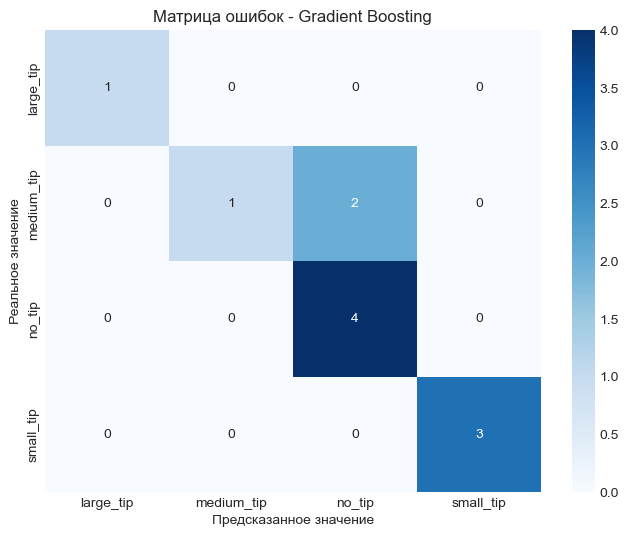

In [25]:
# Ячейка 22: Модель 3 - Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=3)
gb_model.fit(X_train, y_train)

# Предсказание
gb_pred = gb_model.predict(X_test)

# Метрики
gb_accuracy = accuracy_score(y_test, gb_pred)

print("GRADIENT BOOSTING:")
print(f"Accuracy: {gb_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, gb_pred, target_names=le.classes_))

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок - Gradient Boosting')
plt.ylabel('Реальное значение')
plt.xlabel('Предсказанное значение')
plt.show()

СРАВНЕНИЕ МОДЕЛЕЙ КЛАССИФИКАЦИИ:
Модель               Accuracy       
--------------------------------------------------
Decision Tree        0.909          
Random Forest        0.727          
Gradient Boosting    0.818          


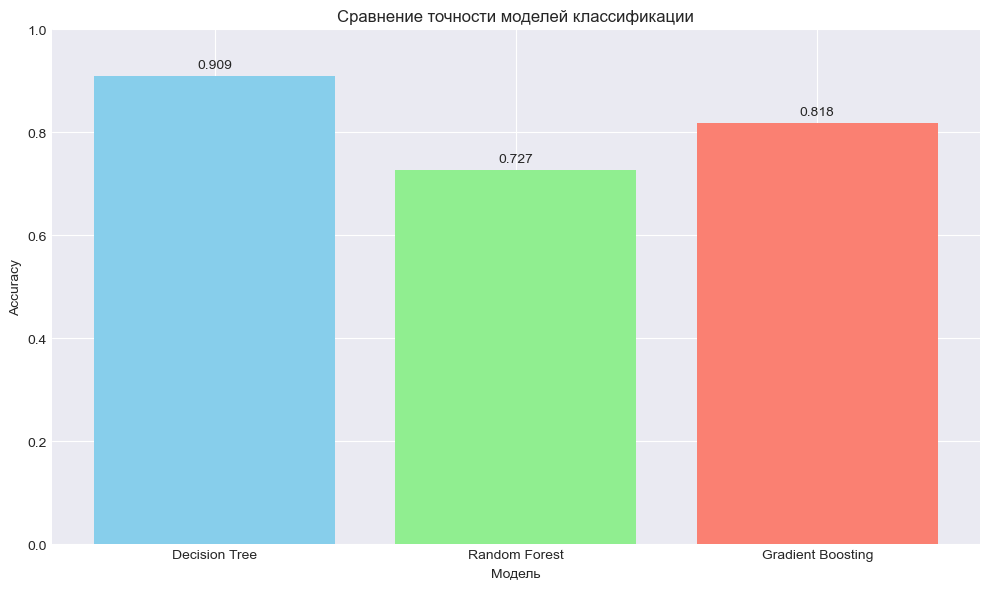

In [26]:
# Ячейка 23: Сравнение моделей классификации
print("СРАВНЕНИЕ МОДЕЛЕЙ КЛАССИФИКАЦИИ:")
print("=" * 50)
print(f"{'Модель':<20} {'Accuracy':<15}")
print("-" * 50)
print(f"{'Decision Tree':<20} {dt_accuracy:<15.3f}")
print(f"{'Random Forest':<20} {rf_accuracy:<15.3f}")
print(f"{'Gradient Boosting':<20} {gb_accuracy:<15.3f}")

# Визуализация сравнения
models = ['Decision Tree', 'Random Forest', 'Gradient Boosting']
accuracies = [dt_accuracy, rf_accuracy, gb_accuracy]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1)
plt.title('Сравнение точности моделей классификации')
plt.ylabel('Accuracy')
plt.xlabel('Модель')

# Добавляем значения на столбцы
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [27]:
# Ячейка 24: Сохранение лучшей модели
# Выбираем лучшую модель (например, Random Forest)
best_model = rf_model

# Сохраняем модель
joblib.dump(best_model, 'best_taxi_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Модель сохранена как 'best_taxi_model.pkl'")
print("Scaler сохранен как 'scaler.pkl'")
print("Label encoder сохранен как 'label_encoder.pkl'")

# Пример загрузки и использования модели
print("\nПример загрузки модели:")
loaded_model = joblib.load('best_taxi_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
loaded_le = joblib.load('label_encoder.pkl')
print("Модель успешно загружена!")

Модель сохранена как 'best_taxi_model.pkl'
Scaler сохранен как 'scaler.pkl'
Label encoder сохранен как 'label_encoder.pkl'

Пример загрузки модели:
Модель успешно загружена!


In [28]:
# Ячейка 25: Тестирование модели на новых данных
# Создаем пример новых данных
new_trip = pd.DataFrame({
    'passenger_count': [2],
    'trip_distance': [5.5],
    'fare_amount': [18.5],
    'pickup_hour': [14],
    'pickup_weekday': [3],
    'trip_duration_minutes': [25]
})

# Предсказание
prediction = best_model.predict(new_trip)
predicted_category = le.inverse_transform(prediction)

print("Тестирование на новых данных:")
print(f"Данные поездки: {new_trip.iloc[0].to_dict()}")
print(f"Предсказанная категория чаевых: {predicted_category[0]}")

Тестирование на новых данных:
Данные поездки: {'passenger_count': 2.0, 'trip_distance': 5.5, 'fare_amount': 18.5, 'pickup_hour': 14.0, 'pickup_weekday': 3.0, 'trip_duration_minutes': 25.0}
Предсказанная категория чаевых: medium_tip
